git add micrograd-master/
git commit -m "更新说明"
git push origin main

In [1]:
class Car: 
    """一次模拟汽车的简单尝试""" 
 
    def __init__(self, make, model, year): 
        """初始化描述汽车的属性""" 
        self.make = make 
        self.model = model 
        self.year = year 
         
    def get_descriptive_name(self): 
        """返回整洁的描述性信息""" 
        long_name = str(self.year) + ' ' + self.make + ' ' + self.model 
        return long_name.title()

my_new_car = Car('audi', 'a4', 2016) 
print(my_new_car)
my_new_car


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):  #
        return f"Value(data={self.data})"
    

    def __add__(self,other):
        out = Value(self.data + other.data,(self,other),'+') ## 创建并返回一个新的 Value 对象，其 data 为两者相加之和

        def _backward():
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out._backward = _backward

        return out
    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t =(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1-t**2)*out.grad
        out._backward = _backward

        return out
    
    

a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
#a+b 相当于a.__add__(b)
e=a*b; e.label='e' #相当于a.__mul__(b)
d = e +c; d.label='d' #相当于(a.__mul__(b)).__add__(c)
f=Value(-2.0,label='f')
L = d*f;L.label='L'
L


Value(data=-8.0)

In [37]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [38]:
d._op


'+'

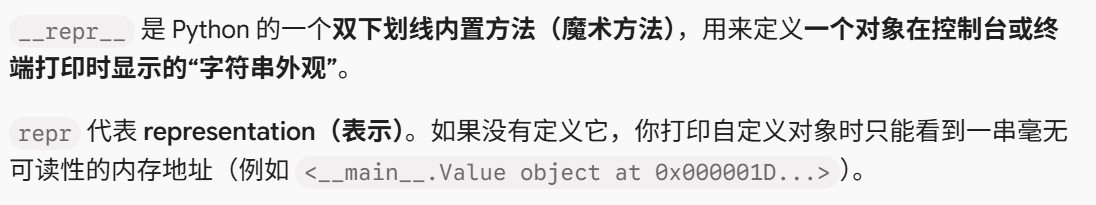
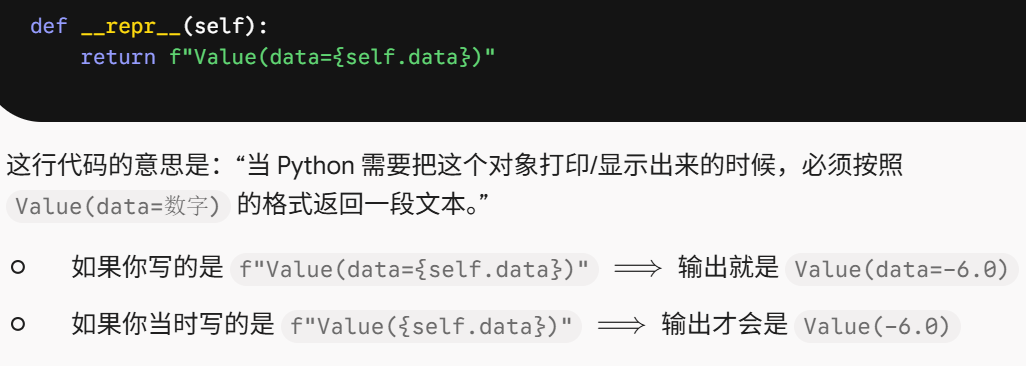
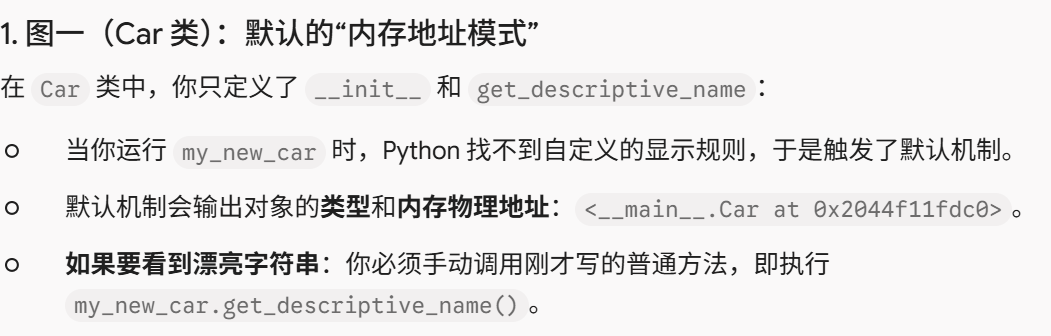
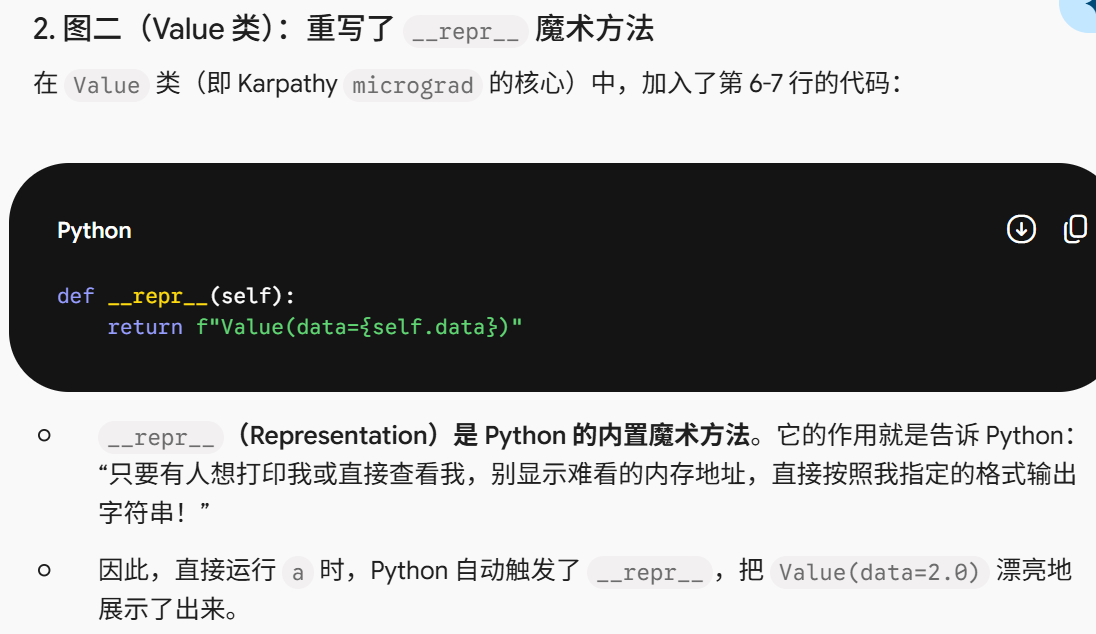
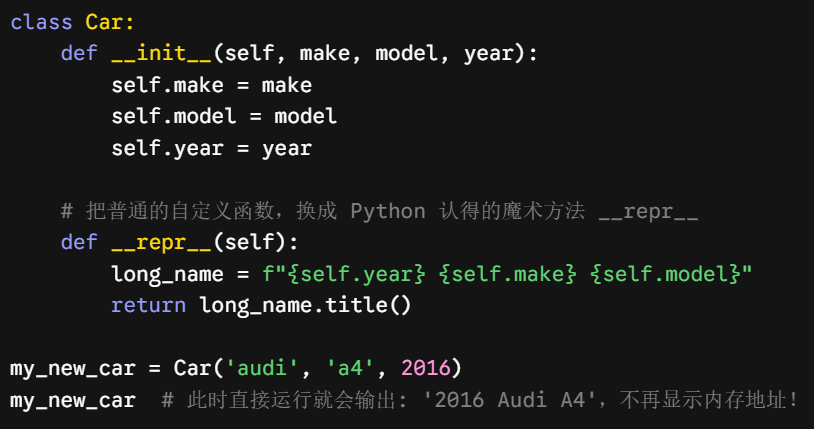

这里a+b报错是因为 Python 不知道两个自定义对象相加 (+) 到底该怎么算。在 Python 里，如果你想让自定义的类（Value）支持加法符号 +，你必须在类里面实现魔法方法 __add__。

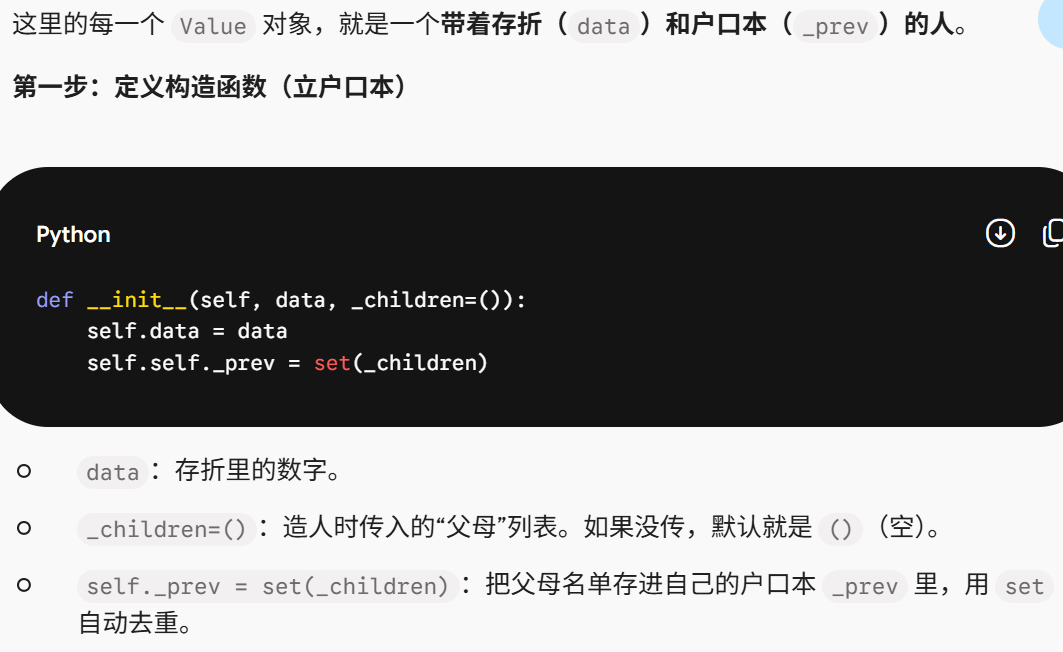
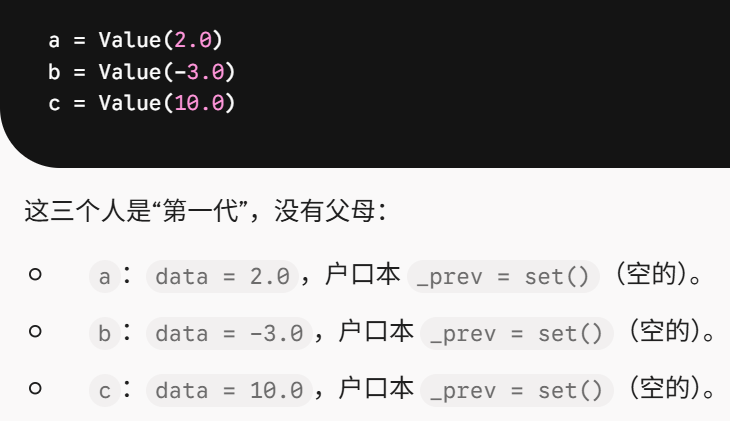
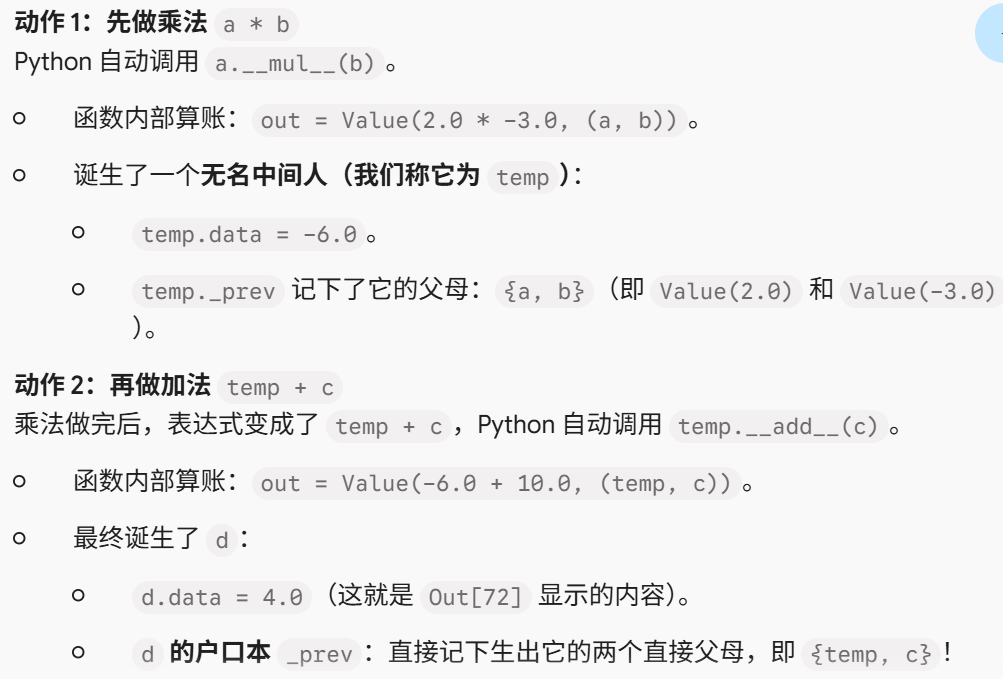
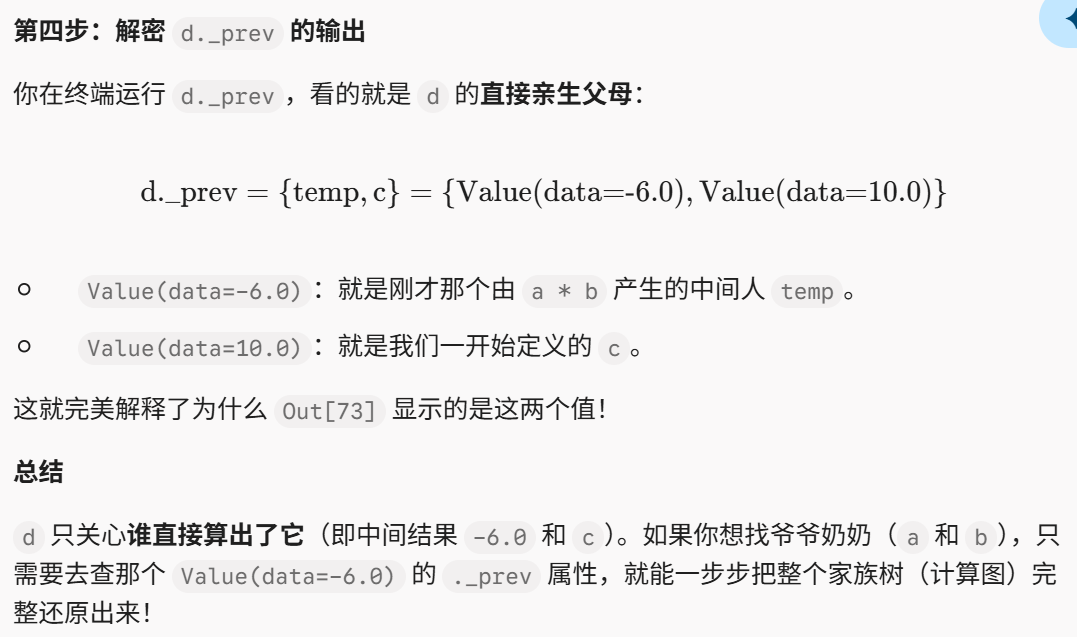
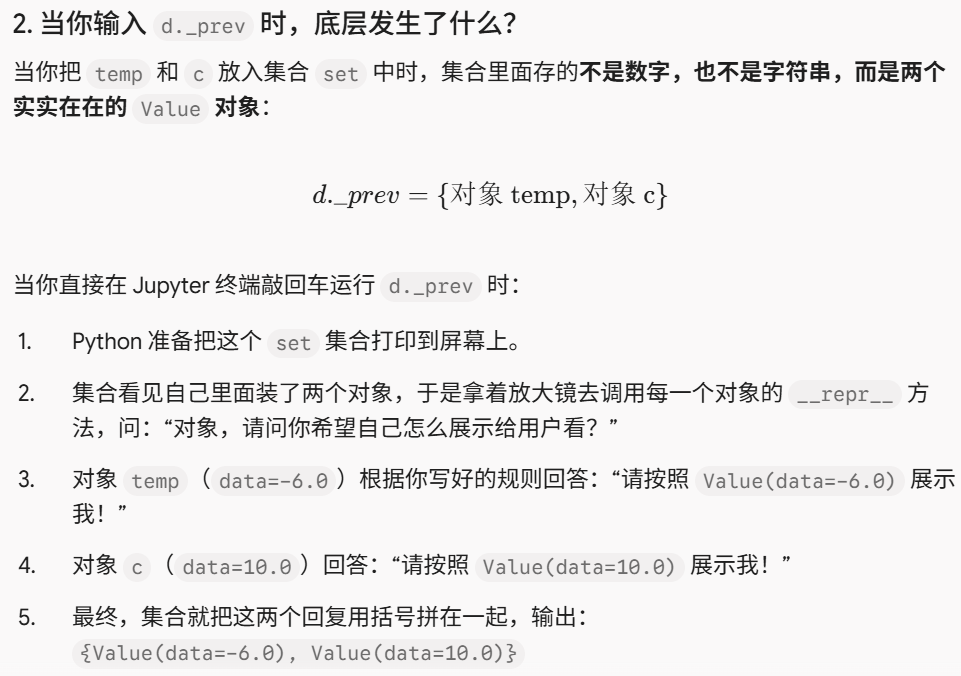
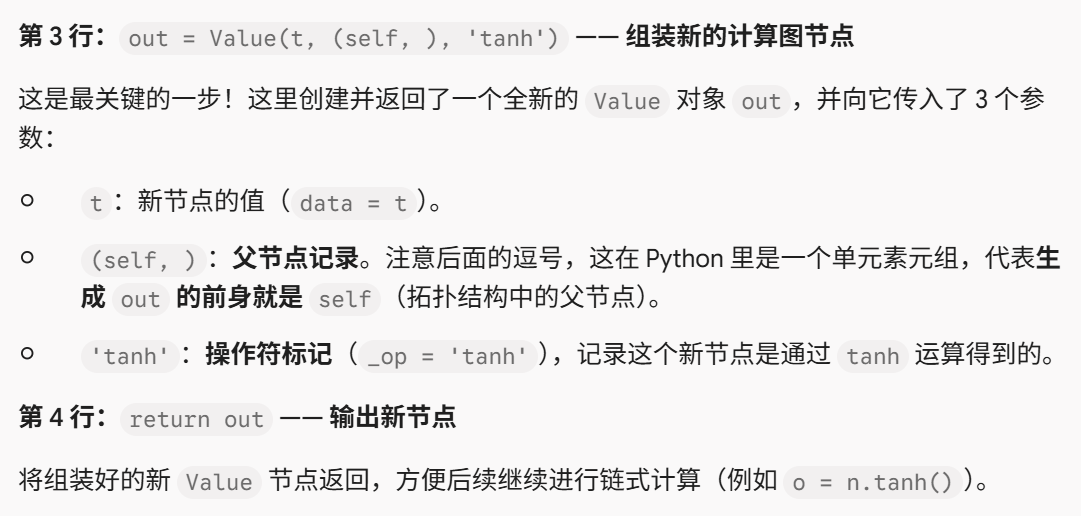
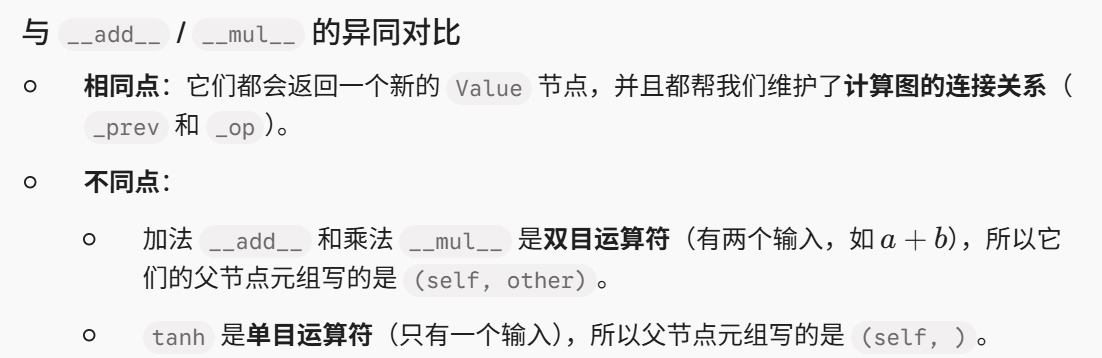
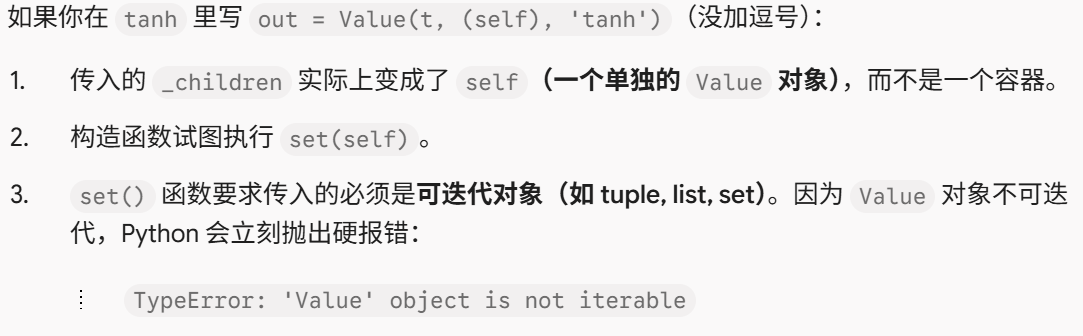
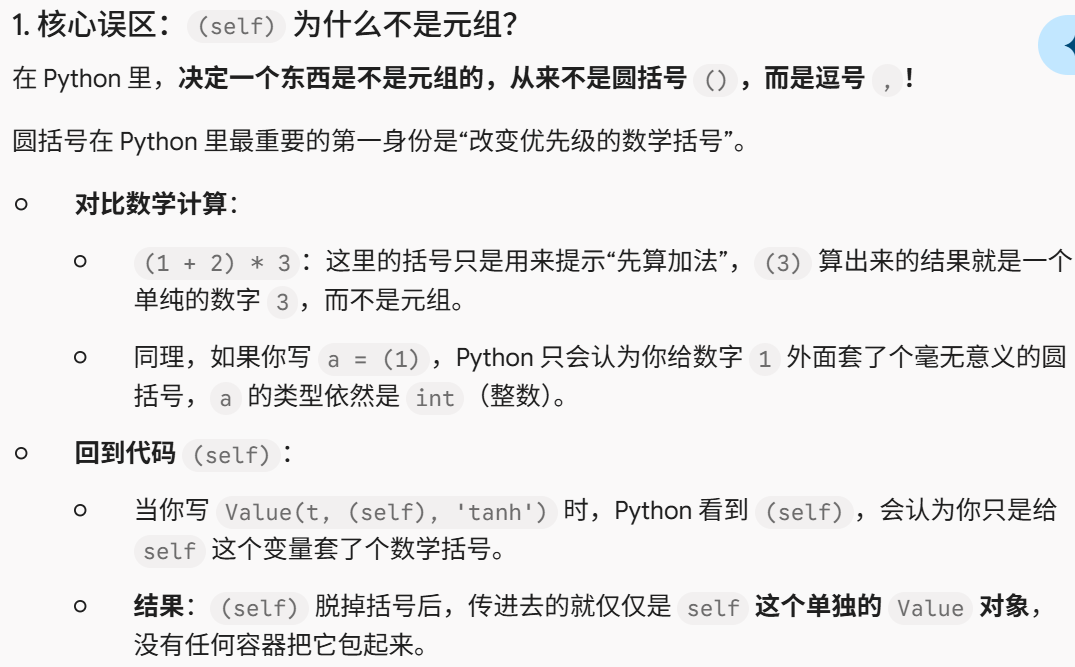
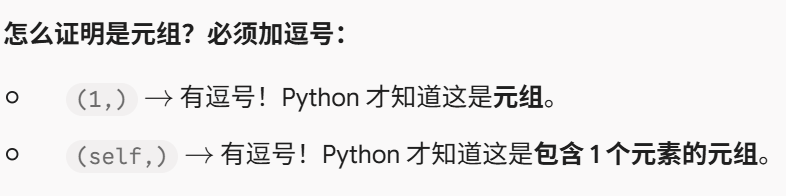
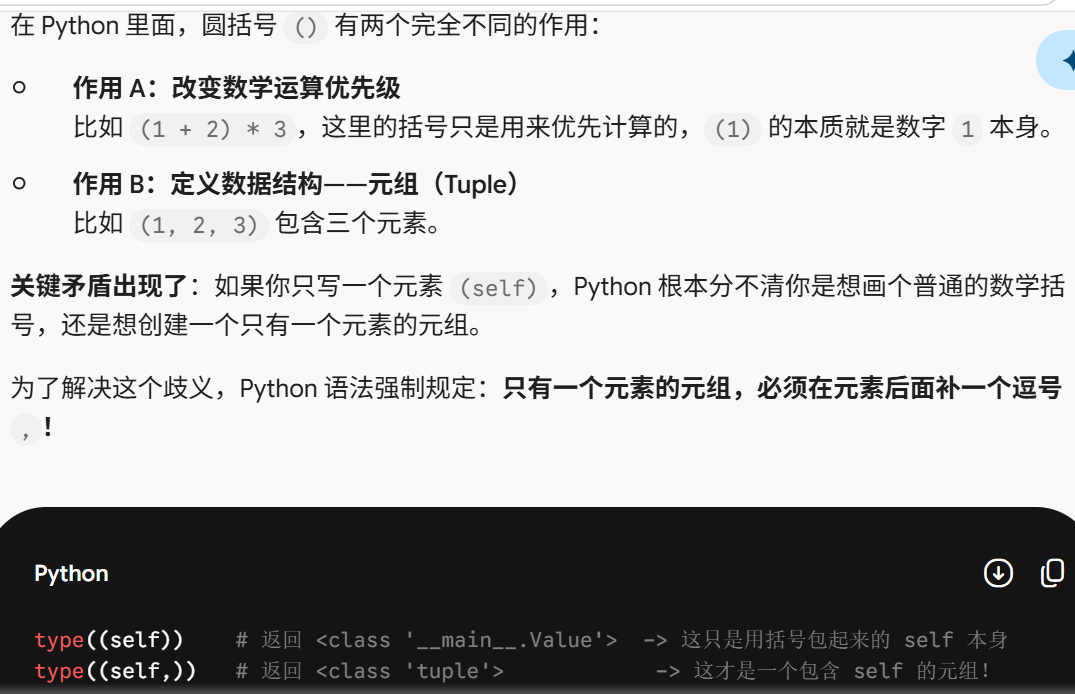

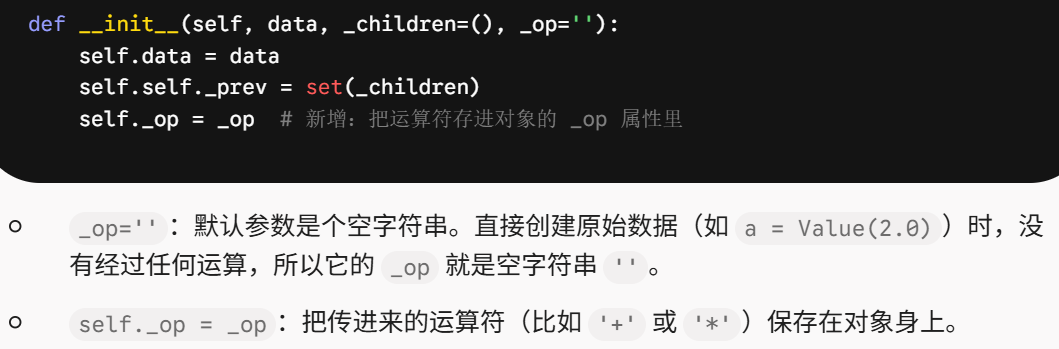
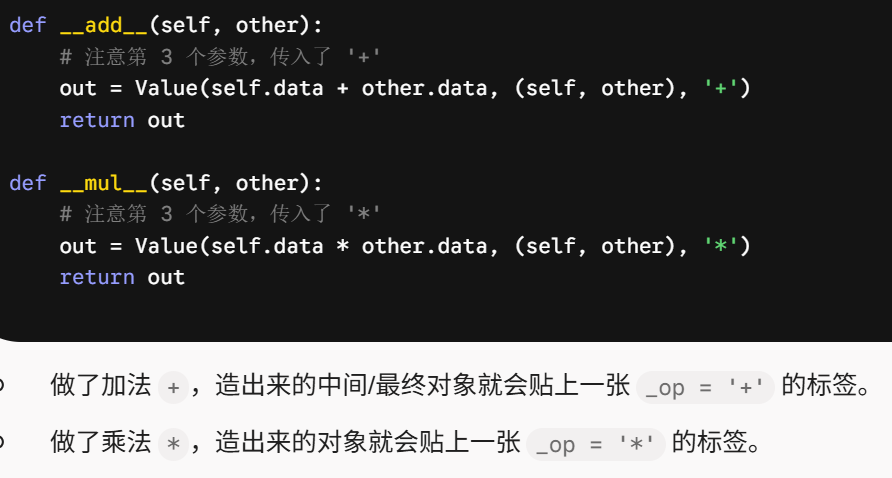
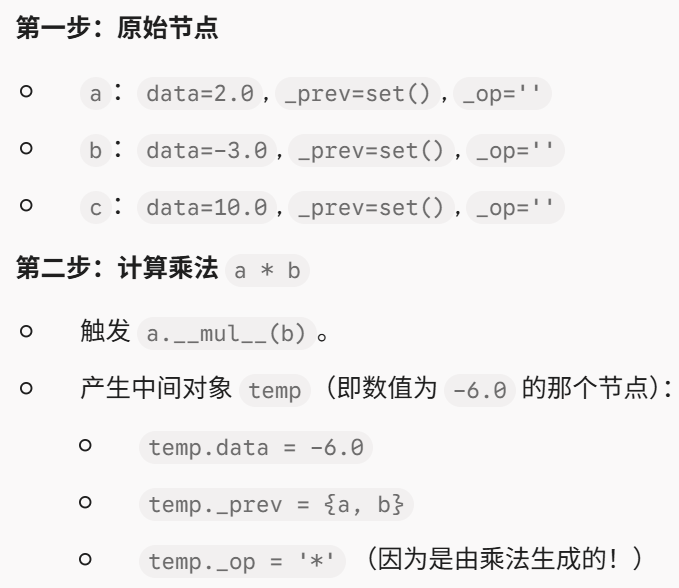
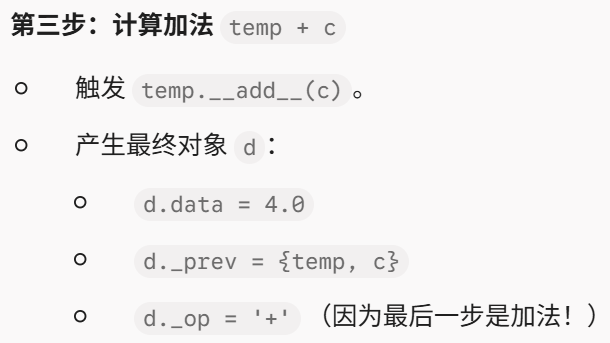
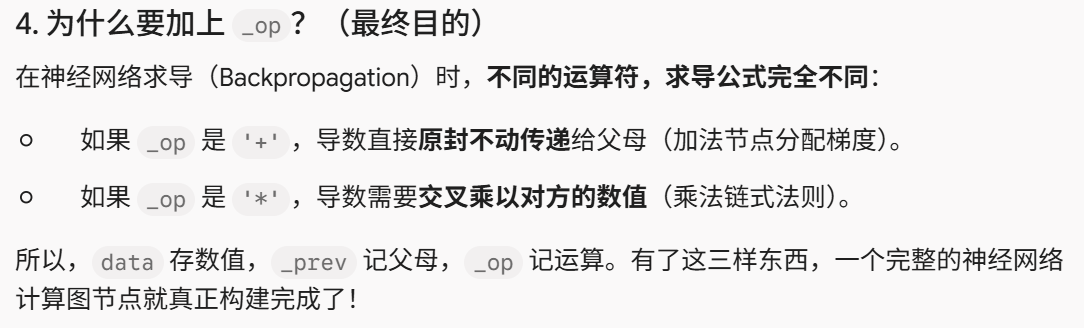
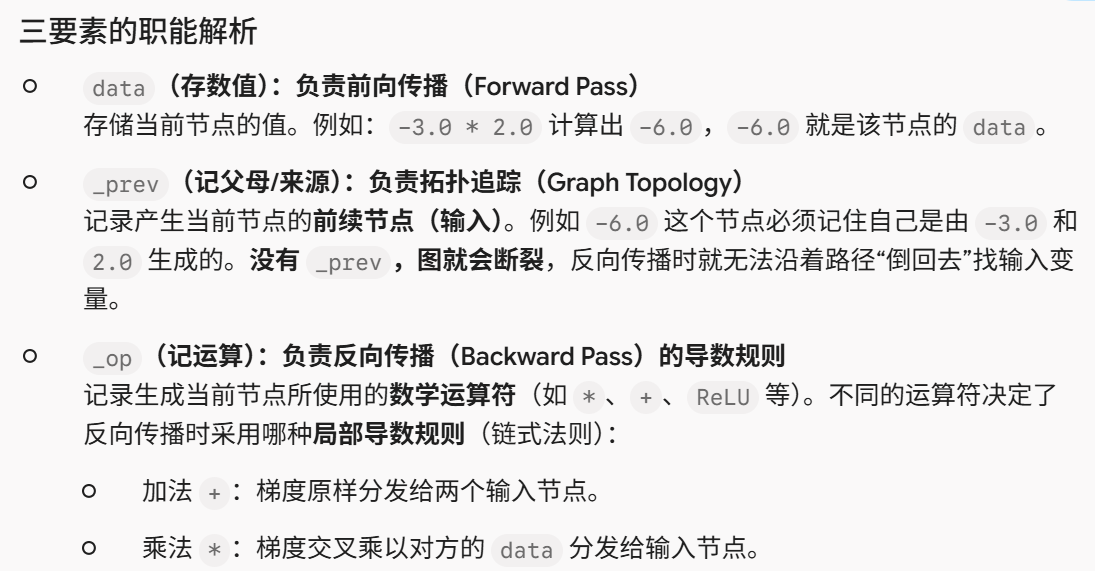
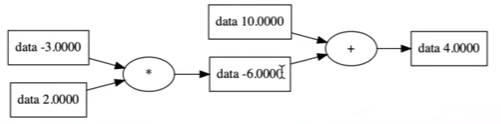
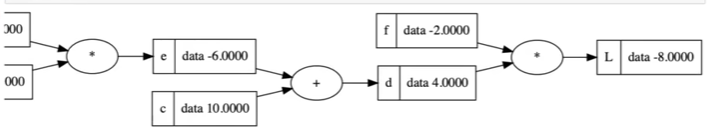

In [39]:
f.grad = 4.0
d.grad = -2.0

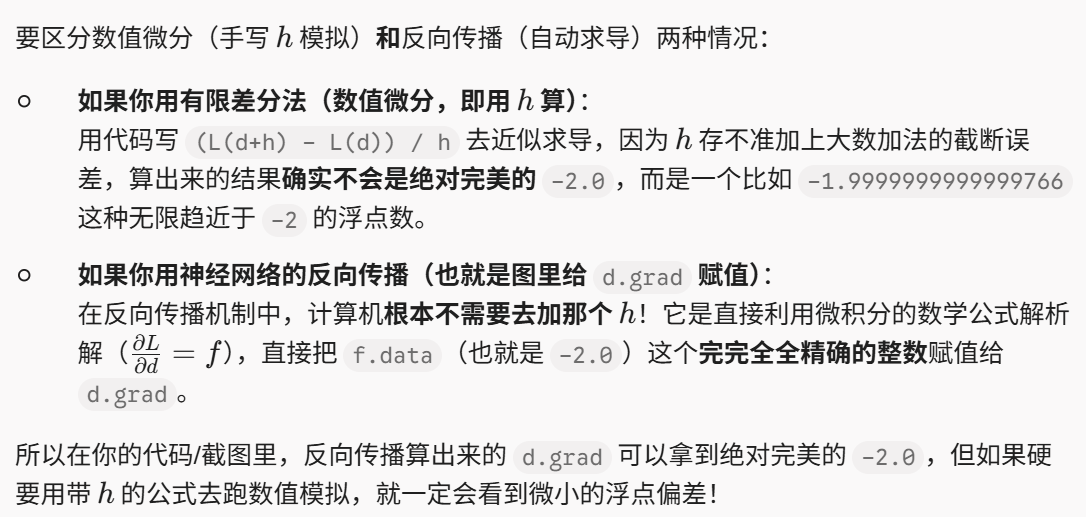
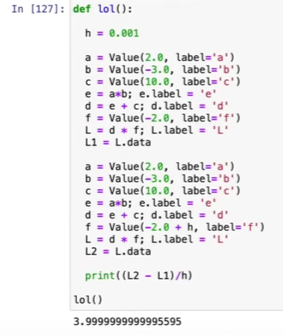
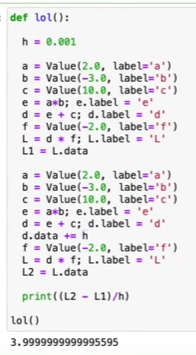


In [40]:
def lol():
    h = 1e-4

    a = Value(2.0,label = 'a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e' 
    d = e +c ; d.label='d'
    f=Value(-2.0,label='f')
    L = d*f;L.label='L'
    L1=L.data

    a = Value(2.0,label = 'a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e' 
    d = e +c ; d.label='d'
    f=Value(-2.0,label='f')
    L = d*f;L.label='L'
    L2=L.data+h
    #print((L.data+h-L.data)/h)

    print((L2-L1)/h)

lol()






0.9999999999976694


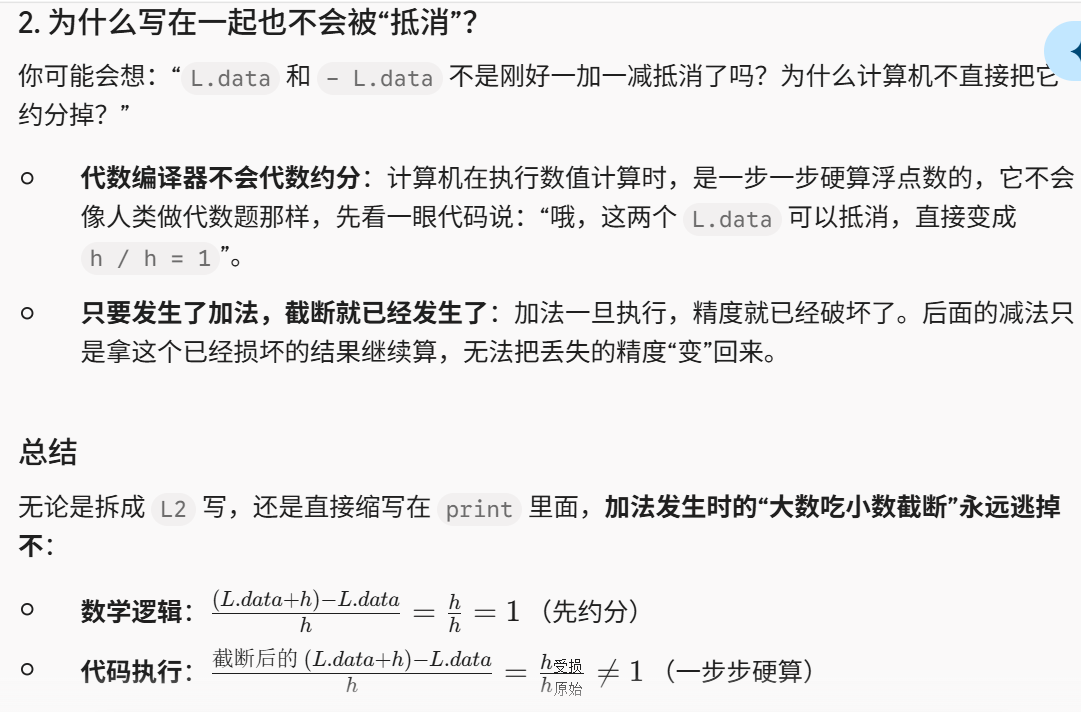

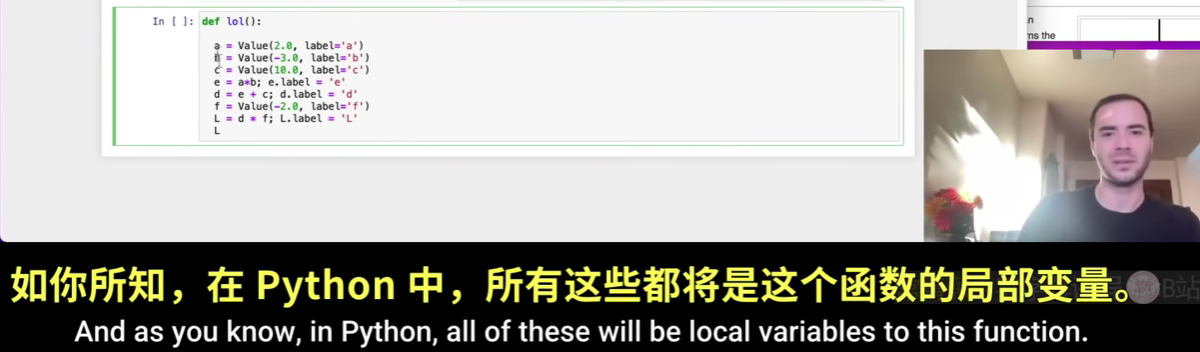
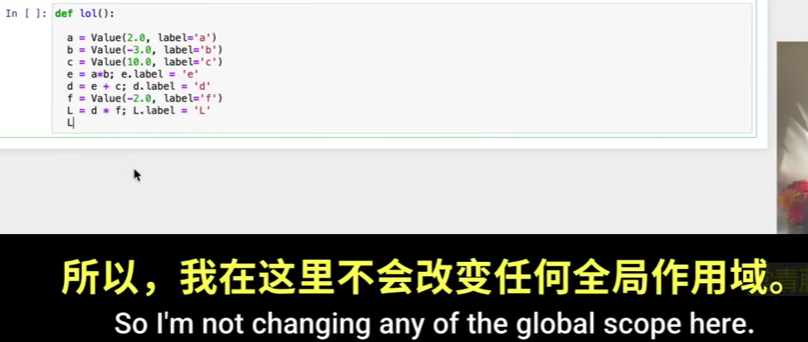
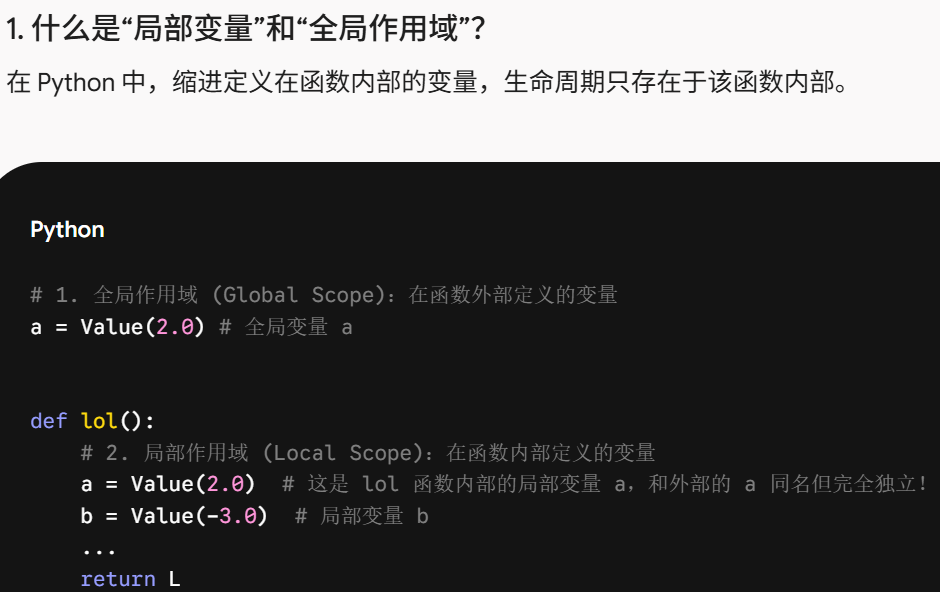
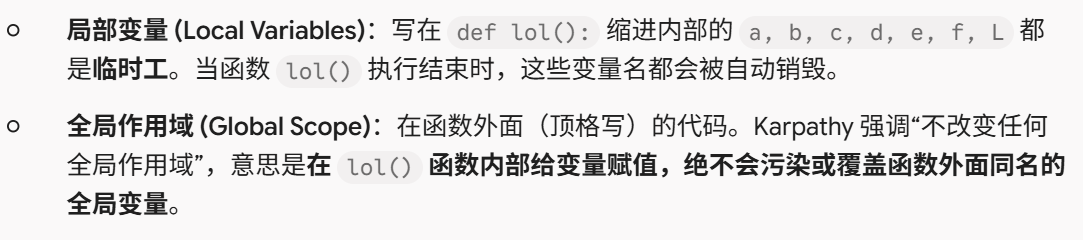



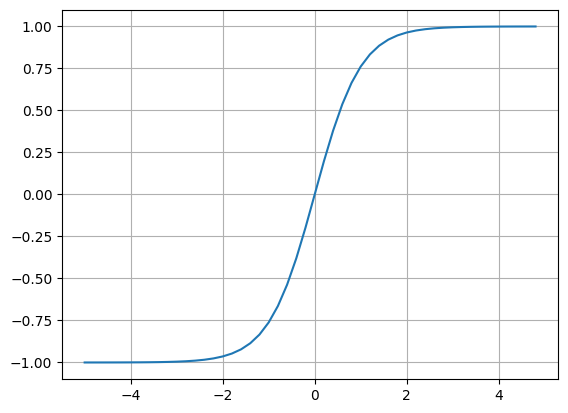

In [41]:
import matplotlib.pyplot as plt
import numpy as np  
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()


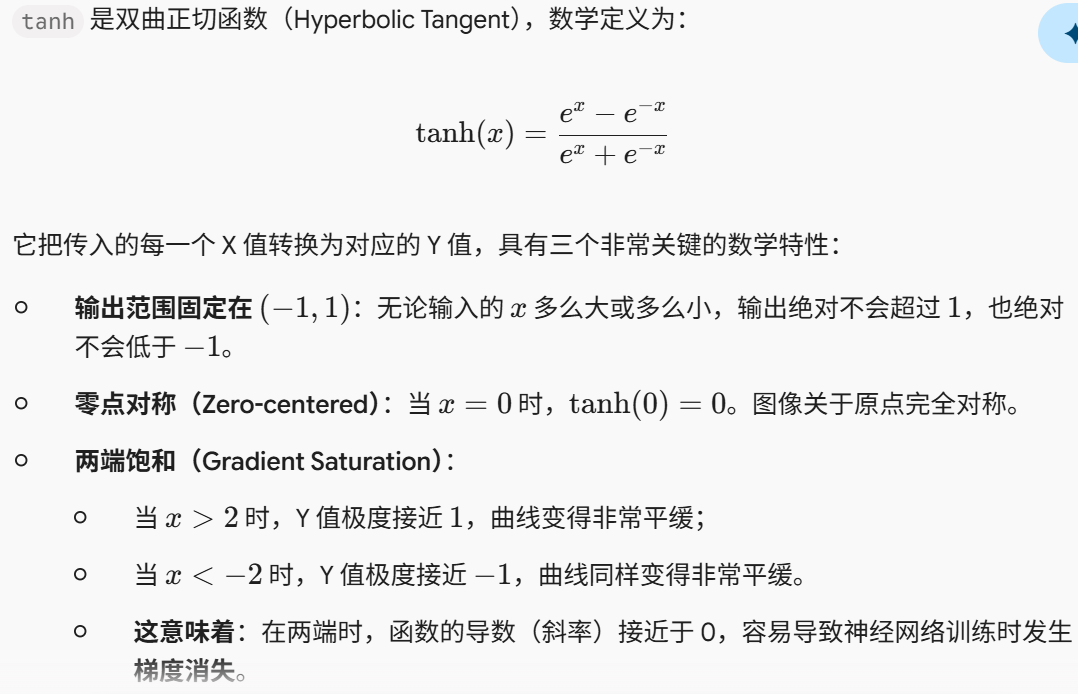
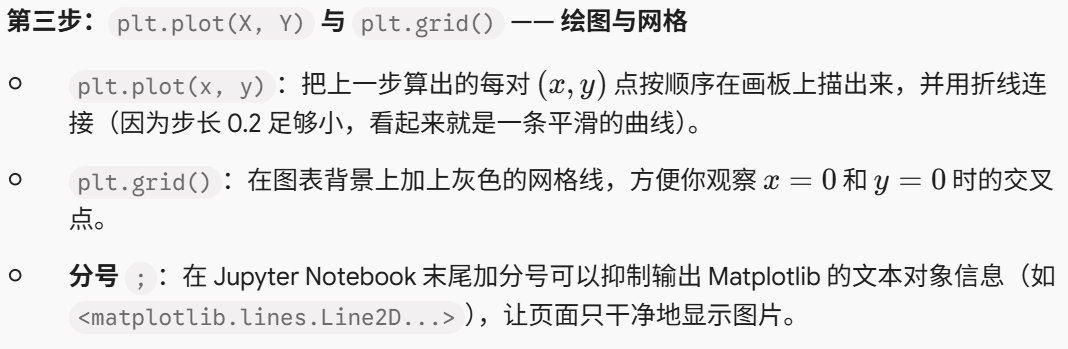
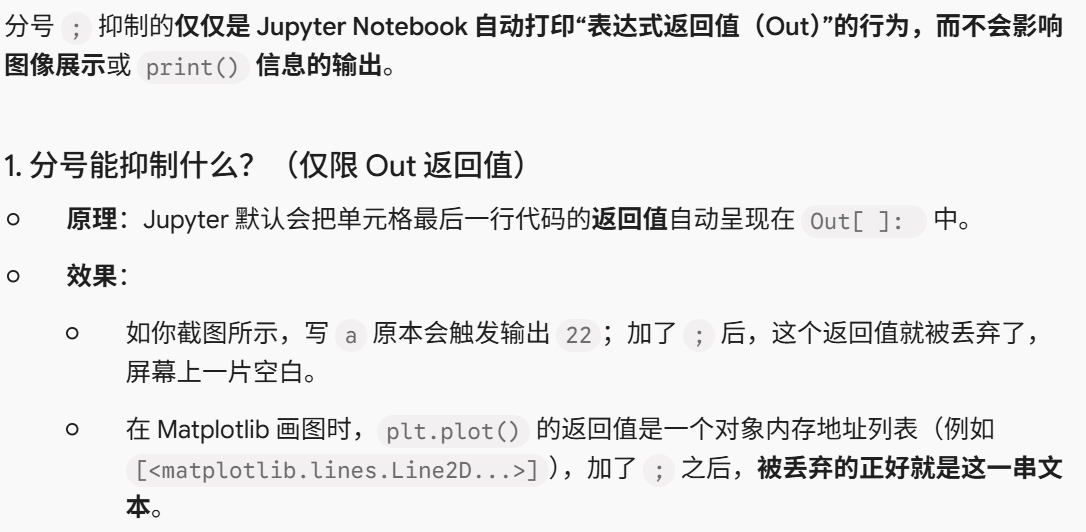



In [ ]:
#inputs x1,x2
x1 = Value(2.0,label = 'x1')
x2 = Value(0.0,label = 'x2')
#weights w1,w2
w1 = Value(-3.0,label = 'w1')
w2 = Value(1.0,label = 'w2')
#bias of the neuron
b = Value(6.7,label = 'b')
# x1*w1 +x2*w2 + b 
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b;n.label = 'n'
o = n.tanh();o.label= 'o'

#o.grad = 1.0  
#n.grad = 0.5  o=tanh(n)  do/dn = 1- o**2
#w1x1w2x2.grad = 0.5
#b.grad = 0.5
#w1x1.grad = 0.5
#w2x2.grad = 0.5
#w1.grad = w1x1.grad*x1.data=1.0    x1.grad = w1x1.grad*w1.data=-1.5
#w2.grad = w2x2.grad*x2.data=0    x2.grad = w2x2.grad*w2.data=0.5



